In [6]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pyedflib import highlevel

from config import PATHS
from config.constants import SAMPLING_FREQUENCY_HZ
from matplotlib_style import apply_style, latex_figsize, FONT_SIZE
from written_thesis.helpers import THESIS_FIGS_DIR

apply_style()

In [7]:
channels = ['Distal Channel', 'Proximal Channel']
n_ch = len(channels)


def plot_one_artifact(axes, pdir, interval_idx=0, pad_samples=500):
    invalid = pd.read_pickle(pdir.invalid_edf_intervals.pickle)[["file_name", "start_idx", "end_idx"]]
    interval = invalid.iloc[interval_idx]

    # Extract the padded artifact interval from the "full" EDF
    file_name = interval.file_name
    abs_start_idx, abs_end_idx = int(interval.start_idx), int(interval.end_idx)

    full_signals, _, _ = highlevel.read_edf(str(pdir.edf_dir / file_name))
    n_ch, full_n_samples = full_signals.shape  # expected 2 channels

    # Clip to file boundaries
    left = max(0, abs_start_idx - pad_samples)
    right = min(full_n_samples, abs_end_idx + pad_samples)

    arti_sigs = full_signals[:, left:right]  # Artifact signals and surrounding area
    n_ch, n_samples = arti_sigs.shape

    # Calculate the local start and end indices of the artifact within the padded artifact interval
    start_idx = abs_start_idx - left
    end_idx = abs_end_idx - left

    start_time, end_time = start_idx / SAMPLING_FREQUENCY_HZ, end_idx / SAMPLING_FREQUENCY_HZ
    time_sec = np.arange(n_samples) / SAMPLING_FREQUENCY_HZ

    for ch_i, ax in enumerate(axes):
        ax.axvspan(start_time, end_time, color='red', alpha=0.5)  # Artifact region
        ax.plot(time_sec, arti_sigs[ch_i, :], color="black", linewidth=0.3)  # Signal
        ax.margins(x=0)

    return axes

In [8]:
def add_row_titles(fig, axes, row_titles, pad=0.01):
    axes = np.atleast_2d(axes)  # handles edge cases like 1 column
    for r, title in enumerate(row_titles):
        pos_left = axes[r, 0].get_position()
        pos_right = axes[r, -1].get_position()

        x_center = (pos_left.x0 + pos_right.x1) / 2
        y_top = pos_left.y1 + pad

        fig.text(x_center, y_top, title, ha="center", va="bottom")


def plot_multiple_artifacts(pdir, iv_idxs, pad_samples: list[int]):
    fig, axes = plt.subplots(
        nrows=n_ch,
        ncols=len(iv_idxs),
        sharey=True,
        width_ratios=[1, 3],
        figsize=latex_figsize(height_ratio=0.5),
    )

    for i, (iv_idx, pad) in enumerate(zip(iv_idxs, pad_samples)):
        plot_one_artifact(axes[:, i], pdir, interval_idx=iv_idx, pad_samples=pad)

    # Adjust ticks
    for ax in axes[:-1, :].ravel():
        ax.tick_params(axis='x', which='both', labelbottom=False)

    # Add margins to prevent label/title overlap with ticks
    fig.subplots_adjust(left=0.15, bottom=0.15, right=0.99, top=0.92,
                        hspace=0.25,
                        wspace=0.05,  # Reduce space between columns
                        )

    fig.supylabel(r'Voltage ($\mu$V)', y=0.6, fontsize=FONT_SIZE)
    fig.supxlabel('time (s)', x=0.6, fontsize=FONT_SIZE)
    add_row_titles(fig, axes, channels)

    return fig

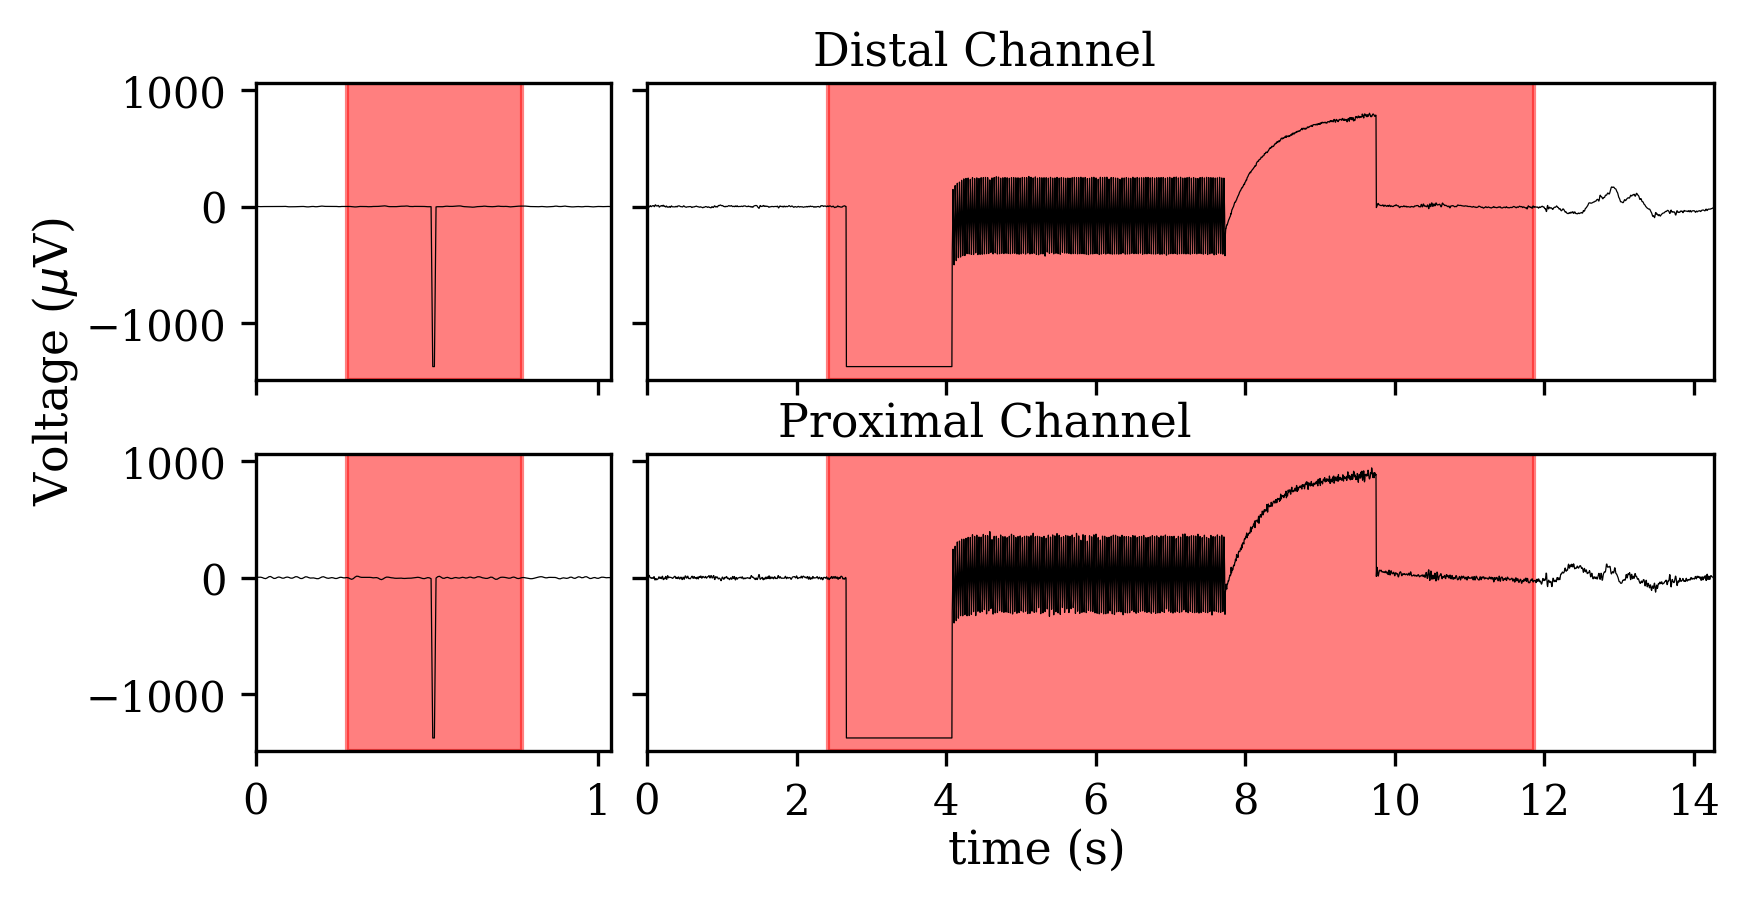

In [9]:
# Make the final plot
pdir = PATHS.patient_dirs(include_fake_ptnts=False)[0]
fig = plot_multiple_artifacts(pdir, iv_idxs=[1, 6], pad_samples=[55, 500])
fig.show()

In [10]:
# Save figure
fig.savefig(
    THESIS_FIGS_DIR / 'artifact_examples.pdf',
    # bbox_inches='tight'
)

In [ ]:
fig, axes = plt.subplots(nrows=n_ch, ncols=1, sharey=True, figsize=(6, 4))
plot_one_artifact(axes, pdir, interval_idx=1, pad_samples=50)
fig.show()

In [ ]:
fig, axes = plt.subplots(nrows=n_ch, ncols=1, sharey=True, figsize=(6, 4))
plot_one_artifact(axes, pdir, interval_idx=6, pad_samples=500)
fig.show()

In [ ]:
# examples = range(50)
examples = [1, 6]

for iv_idx in examples:
    fig, axes = plt.subplots(nrows=n_ch, ncols=1, sharey=True, figsize=(6, 4))
    plot_one_artifact(axes, pdir, interval_idx=iv_idx, pad_samples=500)
    fig.show()